# Analyze identifiability diagnostic CSVs

This notebook aggregates diagnostic CSV files generated by `run_expr(...)`, using the recommended one-file-per-seed/job format stored under a raw-data folder:

```text
../data/raw/solver{solver}_J{J}_K{K}_p{p}_seed{seed}_diag.csv
```

It produces the numerical summaries needed for:

1. **Algorithm diagnostics**: identifiable proportion, branch proportions, average basis size $J_b$, average representative-class count $M=|\mathcal R(Q^{\mathrm{basis}})|$, identity-submatrix proportions, two-column violation proportions, SAT-pass proportions, and runtime summaries.
2. **Pure-node gap diagnostics**: empirical proportions measuring how often identifiable matrices fail completeness or contain no pure nodes.

Raw seed-level files are read from `../data/raw/`; merged and summarized outputs are written to `../data/processed/` by default.


In [17]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 4)

## 1. Configuration

Set `DATA_DIR` to the folder containing your seed-specific diagnostic CSV files. With the recommended simulation output path, this is usually:

```python
DATA_DIR = Path("../data/raw")
```

The notebook writes merged and summarized outputs to `OUT_DIR`, which defaults to `../data/processed` when the raw files are in `../data/raw`.

Use `CSV_GLOB` to restrict which files are loaded. Examples:

```python
CSV_GLOB = "solver*_diag.csv"                         # all diagnostic CSVs in raw/
CSV_GLOB = "solver-1_J50_K10_p0.7_seed*_diag.csv"     # one setting
CSV_GLOB = "solver-1_J*_K10_p*_seed*_diag.csv"        # selected K and solver
```


In [18]:
# Preferred layout for seed-specific raw files:
#   ../data/raw/solver{solver}_J{J}_K{K}_p{p}_seed{seed}_diag.csv
#
# If you run this notebook from a project-level directory instead of notebooks/,
# the fallback data/raw path is also supported.
if Path("../data/raw").exists():
    DATA_DIR = Path("../data/raw")
    OUT_DIR = Path("../data/processed")
elif Path("data/raw").exists():
    DATA_DIR = Path("data/raw")
    OUT_DIR = Path("data/processed")
elif Path("../data").exists():
    # Fallback for the older layout where CSVs were stored directly in ../data.
    DATA_DIR = Path("../data")
    OUT_DIR = Path("../tables")
elif Path("data").exists():
    DATA_DIR = Path("data")
    OUT_DIR = Path("tables")
else:
    DATA_DIR = Path("../data/raw")
    OUT_DIR = Path("../data/processed")

OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_GLOB = "solver*_diag.csv"

# If True, duplicate rows with the same (solver, J, K, p, seed, sim) are dropped.
# This protects against accidentally rerunning the same seed and appending again.
DROP_DUPLICATES = True

# Rounding avoids tiny floating-point differences in p values during grouping.
ROUND_P_DECIMALS = 8

print(f"Current working directory: {Path.cwd()}")
print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"OUT_DIR:  {OUT_DIR.resolve()}")
print(f"CSV_GLOB: {CSV_GLOB}")


Current working directory: /home/lemonkey/idQ
DATA_DIR: /home/lemonkey/idQ/data/raw
OUT_DIR:  /home/lemonkey/idQ/data/processed
CSV_GLOB: solver*_diag.csv


## 2. Load and clean CSV files

This cell loads all matching diagnostic CSV files, adds a `source_file` column, parses the solver from filenames when needed, converts numeric columns, and removes accidental repeated header rows.

In [19]:
def parse_solver_from_filename(filename):
    """
    Parse solver code from names such as:
        solver-1_J50_K10_p0.7_seed1_diag.csv
        solver0_J50_K10_p0.7_diag.csv
    Returns np.nan if not found.
    """
    m = re.search(r"solver(?P<solver>-?\d+)_", filename)
    if m:
        return int(m.group("solver"))
    return np.nan


files = sorted(DATA_DIR.glob(CSV_GLOB))

if not files:
    raise FileNotFoundError(
        f"No CSV files matched {CSV_GLOB!r} in {DATA_DIR.resolve()}.\n"
        "Edit DATA_DIR or CSV_GLOB in the configuration cell."
    )

print(f"Found {len(files)} files.")
for f in files[:10]:
    print("  ", f.name)
if len(files) > 10:
    print("  ...")

dfs = []
for f in files:
    tmp = pd.read_csv(f)
    tmp["source_file"] = f.name
    if "solver" not in tmp.columns:
        tmp["solver"] = parse_solver_from_filename(f.name)
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

# Remove accidental repeated header rows, which can occur if old append logic wrote a header more than once.
if "J" in df.columns:
    df = df[df["J"].astype(str) != "J"].copy()

# Numeric conversion for known numeric columns. Missing columns are ignored.
numeric_cols = [
    "solver", "J", "K", "N", "p", "seed", "sim",
    "J_basis", "M_basis",
    "identifiable", "branch", "sat_called",
    "identity_original", "not_complete_original",
    "has_pure_node_original", "no_pure_nodes_original",
    "two_col_violation_original",
    "identity_basis", "two_col_violation_basis",
    "basis_time", "trivial_check_time",
    "two_col_check_time", "three_col_check_time",
    "identity_check_time", "sat_time",
    "preprocess_time", "algorithm_time", "diagnostic_time",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "p" in df.columns:
    df["p"] = df["p"].round(ROUND_P_DECIMALS)

# Convert solver to nullable integer if possible.
if "solver" in df.columns:
    try:
        df["solver"] = df["solver"].astype("Int64")
    except Exception:
        pass

print(f"Loaded shape: {df.shape}")
df.head()

Found 3000 files.
   solver1_J100_K10_p0.1_seed0_diag.csv
   solver1_J100_K10_p0.1_seed10_diag.csv
   solver1_J100_K10_p0.1_seed11_diag.csv
   solver1_J100_K10_p0.1_seed12_diag.csv
   solver1_J100_K10_p0.1_seed13_diag.csv
   solver1_J100_K10_p0.1_seed14_diag.csv
   solver1_J100_K10_p0.1_seed15_diag.csv
   solver1_J100_K10_p0.1_seed16_diag.csv
   solver1_J100_K10_p0.1_seed17_diag.csv
   solver1_J100_K10_p0.1_seed18_diag.csv
  ...
Loaded shape: (30000, 30)


,J,K,N,p,seed,sim,basis_time,trivial_check_time,two_col_check_time,three_col_check_time,identity_check_time,sat_time,J_basis,algorithm_time,identifiable,branch,branch_label,sat_called,identity_original,not_complete_original,has_pure_node_original,no_pure_nodes_original,two_col_violation_original,identity_basis,two_col_violation_basis,M_basis,preprocess_time,diagnostic_time,source_file,solver
0,100,10,10,0.1,0,0,0.0017,1.4179e-04,0.0006,0.0012,1.3078e-04,0.0,10,0.0039,1,4,identity_submatrix_direct_id,0,0,1,1,0,0,1,0,1024,0.0039,0.0041,solver1_J100_K10_p0.1_seed0_diag.csv,1
1,100,10,10,0.1,0,1,0.0014,8.6828e-05,0.0005,0.0013,8.4515e-05,0.0,10,0.0034,1,4,identity_submatrix_direct_id,0,0,1,1,0,0,1,0,1024,0.0034,0.0040,solver1_J100_K10_p0.1_seed0_diag.csv,1
2,100,10,10,0.1,0,2,0.0016,9.4710e-05,0.0006,0.0012,7.6252e-05,0.0,10,0.0036,1,4,identity_submatrix_direct_id,0,0,1,1,0,0,1,0,1024,0.0036,0.0041,solver1_J100_K10_p0.1_seed0_diag.csv,1
3,100,10,10,0.1,0,3,0.0016,9.3629e-05,0.0006,0.0012,7.5466e-05,0.0,10,0.0036,1,4,identity_submatrix_direct_id,0,0,1,1,0,0,1,0,1024,0.0036,0.0040,solver1_J100_K10_p0.1_seed0_diag.csv,1
4,100,10,10,0.1,0,4,0.0016,9.3967e-05,0.0006,0.0012,7.4425e-05,0.0,10,0.0036,1,4,identity_submatrix_direct_id,0,0,1,1,0,0,1,0,1024,0.0036,0.0040,solver1_J100_K10_p0.1_seed0_diag.csv,1


## 3. Validate required columns and handle duplicate rows

For parallel runs, each seed/job should write to its own CSV. This notebook can then combine them safely. If the same seed was rerun and appended twice, duplicates are detected by the simulation key.

In [20]:
# Some columns can be reconstructed if they were not explicitly saved.
if "sat_called" not in df.columns and "branch" in df.columns:
    df["sat_called"] = df["branch"].isin([5, 6]).astype(int)

if "not_complete_original" not in df.columns and "identity_original" in df.columns:
    df["not_complete_original"] = (1 - df["identity_original"].astype(int)).astype(int)

if "no_pure_nodes_original" not in df.columns and "has_pure_node_original" in df.columns:
    df["no_pure_nodes_original"] = (1 - df["has_pure_node_original"].astype(int)).astype(int)

# Reconstruct preprocess_time if absent but component times exist.
time_components = [
    "basis_time",
    "trivial_check_time",
    "two_col_check_time",
    "three_col_check_time",
    "identity_check_time",
]
if "preprocess_time" not in df.columns and all(c in df.columns for c in time_components):
    df["preprocess_time"] = df[time_components].sum(axis=1)

required_for_algorithm = [
    "solver", "J", "K", "p", "seed", "sim",
    "identifiable", "branch",
    "J_basis", "M_basis",
    "identity_original", "identity_basis",
    "two_col_violation_original", "two_col_violation_basis",
    "sat_called",
    "algorithm_time", "preprocess_time", "sat_time",
]

required_for_pure_gap = [
    "solver", "J", "K", "p", "seed", "sim",
    "identifiable", "not_complete_original", "no_pure_nodes_original",
]

missing_algorithm = [c for c in required_for_algorithm if c not in df.columns]
missing_pure_gap = [c for c in required_for_pure_gap if c not in df.columns]

if missing_algorithm:
    warnings.warn(
        "Missing columns for the full algorithm diagnostics table:\n"
        + ", ".join(missing_algorithm)
    )

if missing_pure_gap:
    warnings.warn(
        "Missing columns for the pure-node gap table:\n"
        + ", ".join(missing_pure_gap)
    )

# Duplicate detection.
key = ["solver", "J", "K", "p", "seed", "sim"]
missing_key = [c for c in key if c not in df.columns]
if missing_key:
    raise ValueError(f"Cannot check duplicates because key columns are missing: {missing_key}")

dup_mask = df.duplicated(key, keep=False)
dup_count = int(dup_mask.sum())

print(f"Duplicate rows under key {key}: {dup_count}")

if dup_count > 0:
    display(
        df.loc[dup_mask, key + ["source_file"]]
          .sort_values(key)
          .head(20)
    )
    if DROP_DUPLICATES:
        before = len(df)
        df = df.drop_duplicates(key, keep="last").copy()
        after = len(df)
        print(f"Dropped {before - after} duplicate rows; kept last occurrence.")
    else:
        print("DROP_DUPLICATES=False, so duplicates were retained.")

print(f"Final shape after duplicate handling: {df.shape}")

Duplicate rows under key ['solver', 'J', 'K', 'p', 'seed', 'sim']: 0
Final shape after duplicate handling: (30000, 30)


## 4. Simulation counts by setting and seed

Use this table to verify that every seed produced the intended number of rows. The `N` column is the nominal number requested in each job; after combining seeds, the actual sample size for each \((J,K,p,\text{solver})\) is the number of rows.

In [21]:
seed_counts = (
    df.groupby(["solver", "J", "K", "p", "seed"], dropna=False)
      .size()
      .reset_index(name="n_rows")
      .sort_values(["solver", "K", "J", "p", "seed"])
      .reset_index(drop=True)
)

display(seed_counts)

setting_counts = (
    df.groupby(["solver", "J", "K", "p"], dropna=False)
      .size()
      .reset_index(name="total_rows")
      .sort_values(["solver", "K", "J", "p"])
      .reset_index(drop=True)
)

display(setting_counts)

,solver,J,K,p,seed,n_rows
0,1,25,5,0.1,0,10
1,1,25,5,0.1,1,10
2,1,25,5,0.1,2,10
3,1,25,5,0.1,3,10
4,1,25,5,0.1,4,10
...,...,...,...,...,...,...
2995,1,100,10,0.9,95,10
2996,1,100,10,0.9,96,10
2997,1,100,10,0.9,97,10
2998,1,100,10,0.9,98,10


,solver,J,K,p,total_rows
0,1,25,5,0.1,1000
1,1,25,5,0.3,1000
2,1,25,5,0.5,1000
3,1,25,5,0.7,1000
4,1,25,5,0.9,1000
5,1,50,5,0.1,1000
6,1,50,5,0.3,1000
7,1,50,5,0.5,1000
8,1,50,5,0.7,1000
9,1,50,5,0.9,1000


## 5. Branch labels and derived indicators

Branches mean where the algorithm stops:

| Branch | Meaning |
|---:|---|
| -1 | \(J_b<K\) after basis reduction |
| 0 | all-zero column in \(Q^{\mathrm{basis}}\) |
| 1 | all-one column in \(Q^{\mathrm{basis}}\) |
| 2 | two-column submatrix check fails |
| 3 | three-column submatrix check fails |
| 4 | identity submatrix found |
| 5 | SAT finds a counterexample \(\bar Q\) |
| 6 | SAT is unsatisfiable, hence identifiable |

In [22]:
BRANCH_LABELS = {
    -1: "basis_J_less_than_K",
     0: "all_zero_column",
     1: "all_one_column",
     2: "two_column_check_failed",
     3: "three_column_check_failed",
     4: "identity_submatrix_direct_id",
     5: "SAT_found_counterexample",
     6: "SAT_unsat_identifiable",
}

df["branch_label"] = df["branch"].map(BRANCH_LABELS)

df["resolved_before_SAT"] = 1 - df["sat_called"].astype(int)
df["SAT_identifiable"] = (df["branch"] == 6).astype(int)
df["SAT_nonidentifiable"] = (df["branch"] == 5).astype(int)
df["direct_identity_branch"] = (df["branch"] == 4).astype(int)
df["two_col_branch"] = (df["branch"] == 2).astype(int)
df["three_col_branch"] = (df["branch"] == 3).astype(int)

display(df[["branch", "branch_label"]].value_counts(dropna=False).sort_index().to_frame("count"))

,,count
branch,branch_label,
-1,basis_J_less_than_K,1114
0,all_zero_column,275
1,all_one_column,491
2,two_column_check_failed,2347
3,three_column_check_failed,3680
4,identity_submatrix_direct_id,6666
5,SAT_found_counterexample,1262
6,SAT_unsat_identifiable,14165


## 6. Helper functions for summaries and display formatting

In [23]:
GROUP_COLS = ["solver", "J", "K", "p"]

def binomial_se(x):
    """
    Monte Carlo standard error for a sample proportion.
    x should be a 0/1 or boolean pandas Series.
    """
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    if n == 0:
        return np.nan
    p_hat = x.mean()
    return np.sqrt(p_hat * (1 - p_hat) / n)


def percent_table(tab, percent_cols, digits=1):
    """
    Return a display copy with selected proportion columns converted to percentages.
    Values remain strings in the returned table, so use raw tables for further analysis.
    """
    out = tab.copy()
    for c in percent_cols:
        if c in out.columns:
            out[c] = out[c].map(
                lambda x: "" if pd.isna(x) else f"{100 * x:.{digits}f}"
            )
    return out


def format_float_cols(tab, cols, digits=3):
    out = tab.copy()
    for c in cols:
        if c in out.columns:
            out[c] = out[c].map(
                lambda x: "" if pd.isna(x) else f"{x:.{digits}f}"
            )
    return out

## 7. Reviewer 2: Algorithm diagnostics table

This table summarizes the Bernoulli-\(p\) algorithm behavior:

\[
\widehat P(\mathrm{id}),\quad \bar J_b,\quad \bar M,\quad
\widehat P(\mathcal I_K\subseteq Q),\quad
\widehat P(\text{two-column violation}),\quad
\widehat P(\text{SAT called}),
\]

plus preprocessing and SAT runtime summaries.

In [24]:
algorithm_cols_needed = [
    "identifiable", "J_basis", "M_basis",
    "identity_original", "identity_basis",
    "two_col_violation_original", "two_col_violation_basis",
    "sat_called", "resolved_before_SAT",
    "algorithm_time", "preprocess_time", "sat_time",
]

missing = [c for c in algorithm_cols_needed if c not in df.columns]
if missing:
    raise ValueError(
        "Cannot compute algorithm diagnostics because these columns are missing:\n"
        + ", ".join(missing)
    )

alg_summary = (
    df.groupby(GROUP_COLS, dropna=False)
      .agg(
          n=("identifiable", "size"),
          id_prop=("identifiable", "mean"),
          id_mcse=("identifiable", binomial_se),

          mean_J_basis=("J_basis", "mean"),
          sd_J_basis=("J_basis", "std"),
          mean_M_basis=("M_basis", "mean"),
          sd_M_basis=("M_basis", "std"),

          identity_original_prop=("identity_original", "mean"),
          identity_basis_prop=("identity_basis", "mean"),

          two_col_violation_original_prop=("two_col_violation_original", "mean"),
          two_col_violation_basis_prop=("two_col_violation_basis", "mean"),

          sat_called_prop=("sat_called", "mean"),
          resolved_before_SAT_prop=("resolved_before_SAT", "mean"),

          mean_algorithm_time=("algorithm_time", "mean"),
          median_algorithm_time=("algorithm_time", "median"),
          mean_preprocess_time=("preprocess_time", "mean"),
          median_preprocess_time=("preprocess_time", "median"),
          mean_sat_time_all=("sat_time", "mean"),
          median_sat_time_all=("sat_time", "median"),
      )
      .reset_index()
)

alg_summary["preprocess_share_of_total"] = (
    alg_summary["mean_preprocess_time"] / alg_summary["mean_algorithm_time"]
)

alg_summary = alg_summary.sort_values(GROUP_COLS).reset_index(drop=True)

display(alg_summary)

,solver,J,K,p,n,id_prop,id_mcse,mean_J_basis,sd_J_basis,mean_M_basis,sd_M_basis,identity_original_prop,identity_basis_prop,two_col_violation_original_prop,two_col_violation_basis_prop,sat_called_prop,resolved_before_SAT_prop,mean_algorithm_time,median_algorithm_time,mean_preprocess_time,median_preprocess_time,mean_sat_time_all,median_sat_time_all,preprocess_share_of_total
0,1,25,5,0.1,1000,0.444,0.0157,4.804,0.7773,23.597,7.8362,0.059,0.346,0.556,0.556,0.098,0.902,0.0006,0.0003,0.0003,0.0002,2.5301e-04,0.0000,0.5078
1,1,25,5,0.3,1000,0.951,0.0068,6.161,1.2052,29.323,2.9586,0.030,0.389,0.049,0.049,0.562,0.438,0.0021,0.0027,0.0005,0.0005,1.6331e-03,0.0022,0.2349
2,1,25,5,0.5,1000,0.983,0.0041,7.997,1.2233,25.601,2.8955,0.161,0.032,0.017,0.017,0.951,0.049,0.0037,0.0037,0.0006,0.0005,3.1049e-03,0.0032,0.1518
3,1,25,5,0.7,1000,0.803,0.0126,7.963,1.1554,17.060,2.7070,0.001,0.000,0.049,0.049,0.904,0.096,0.0031,0.0032,0.0005,0.0005,2.5642e-03,0.0026,0.1663
4,1,25,5,0.9,1000,0.000,0.0000,5.393,0.9754,8.160,1.5404,0.000,0.000,0.556,0.556,0.019,0.981,0.0003,0.0003,0.0002,0.0002,4.1695e-05,0.0000,0.6544
5,1,25,10,0.1,1000,0.078,0.0085,10.395,1.6709,354.449,186.0082,0.166,0.006,0.922,0.922,0.072,0.928,0.0113,0.0010,0.0012,0.0009,9.9885e-03,0.0000,0.1081
6,1,25,10,0.3,1000,0.823,0.0121,19.981,1.9366,377.132,77.6961,0.001,0.000,0.177,0.177,0.823,0.177,0.1264,0.1409,0.0048,0.0050,1.2160e-01,0.1362,0.0380
7,1,25,10,0.5,1000,0.933,0.0079,21.481,1.5621,161.133,29.1756,0.000,0.000,0.058,0.058,0.941,0.059,0.1434,0.1188,0.0040,0.0040,1.3945e-01,0.1145,0.0277
8,1,25,10,0.7,1000,0.051,0.0070,18.180,1.8982,56.937,10.2208,0.000,0.000,0.177,0.177,0.538,0.462,0.4226,0.0327,0.0025,0.0028,4.1998e-01,0.0298,0.0059
9,1,25,10,0.9,1000,0.000,0.0000,10.235,1.4947,16.505,3.0082,0.000,0.000,0.922,0.922,0.000,1.000,0.0005,0.0004,0.0004,0.0002,0.0000e+00,0.0000,0.7600


### SAT-conditional runtime

The average SAT time over all simulations can be small when most cases never reach SAT. This table also reports runtime among cases actually passed to SAT.

In [25]:
sat_df = df[df["sat_called"] == 1].copy()

if len(sat_df) == 0:
    sat_summary = pd.DataFrame(columns=GROUP_COLS + [
        "n_SAT",
        "SAT_identifiable_prop",
        "SAT_nonidentifiable_prop",
        "mean_sat_time_given_SAT",
        "median_sat_time_given_SAT",
        "mean_algorithm_time_given_SAT",
        "mean_J_basis_given_SAT",
        "mean_M_basis_given_SAT",
    ])
else:
    sat_summary = (
        sat_df.groupby(GROUP_COLS, dropna=False)
              .agg(
                  n_SAT=("sat_called", "size"),
                  SAT_identifiable_prop=("SAT_identifiable", "mean"),
                  SAT_nonidentifiable_prop=("SAT_nonidentifiable", "mean"),
                  mean_sat_time_given_SAT=("sat_time", "mean"),
                  median_sat_time_given_SAT=("sat_time", "median"),
                  mean_algorithm_time_given_SAT=("algorithm_time", "mean"),
                  mean_J_basis_given_SAT=("J_basis", "mean"),
                  mean_M_basis_given_SAT=("M_basis", "mean"),
              )
              .reset_index()
    )

alg_summary_full = alg_summary.merge(
    sat_summary,
    on=GROUP_COLS,
    how="left"
)

# Fill SAT count where no row reached SAT.
if "n_SAT" in alg_summary_full.columns:
    alg_summary_full["n_SAT"] = alg_summary_full["n_SAT"].fillna(0).astype(int)

display(alg_summary_full)

,solver,J,K,p,n,id_prop,id_mcse,mean_J_basis,sd_J_basis,mean_M_basis,sd_M_basis,identity_original_prop,identity_basis_prop,two_col_violation_original_prop,two_col_violation_basis_prop,sat_called_prop,resolved_before_SAT_prop,mean_algorithm_time,median_algorithm_time,mean_preprocess_time,median_preprocess_time,mean_sat_time_all,median_sat_time_all,preprocess_share_of_total,n_SAT,SAT_identifiable_prop,SAT_nonidentifiable_prop,mean_sat_time_given_SAT,median_sat_time_given_SAT,mean_algorithm_time_given_SAT,mean_J_basis_given_SAT,mean_M_basis_given_SAT
0,1,25,5,0.1,1000,0.444,0.0157,4.804,0.7773,23.597,7.8362,0.059,0.346,0.556,0.556,0.098,0.902,0.0006,0.0003,0.0003,0.0002,2.5301e-04,0.0000,0.5078,98,1.0000,0.0000,0.0026,0.0026,0.0031,6.1837,27.7245
1,1,25,5,0.3,1000,0.951,0.0068,6.161,1.2052,29.323,2.9586,0.030,0.389,0.049,0.049,0.562,0.438,0.0021,0.0027,0.0005,0.0005,1.6331e-03,0.0022,0.2349,562,1.0000,0.0000,0.0029,0.0028,0.0034,7.0196,28.0623
2,1,25,5,0.5,1000,0.983,0.0041,7.997,1.2233,25.601,2.8955,0.161,0.032,0.017,0.017,0.951,0.049,0.0037,0.0037,0.0006,0.0005,3.1049e-03,0.0032,0.1518,951,1.0000,0.0000,0.0033,0.0032,0.0038,8.1188,25.4564
3,1,25,5,0.7,1000,0.803,0.0126,7.963,1.1554,17.060,2.7070,0.001,0.000,0.049,0.049,0.904,0.096,0.0031,0.0032,0.0005,0.0005,2.5642e-03,0.0026,0.1663,904,0.8883,0.1117,0.0028,0.0027,0.0034,8.0763,17.4148
4,1,25,5,0.9,1000,0.000,0.0000,5.393,0.9754,8.160,1.5404,0.000,0.000,0.556,0.556,0.019,0.981,0.0003,0.0003,0.0002,0.0002,4.1695e-05,0.0000,0.6544,19,0.0000,1.0000,0.0022,0.0022,0.0028,6.6316,11.6842
5,1,25,10,0.1,1000,0.078,0.0085,10.395,1.6709,354.449,186.0082,0.166,0.006,0.922,0.922,0.072,0.928,0.0113,0.0010,0.0012,0.0009,9.9885e-03,0.0000,0.1081,72,1.0000,0.0000,0.1387,0.1345,0.1429,12.7083,687.5556
6,1,25,10,0.3,1000,0.823,0.0121,19.981,1.9366,377.132,77.6961,0.001,0.000,0.177,0.177,0.823,0.177,0.1264,0.1409,0.0048,0.0050,1.2160e-01,0.1362,0.0380,823,1.0000,0.0000,0.1478,0.1486,0.1529,20.2126,387.7388
7,1,25,10,0.5,1000,0.933,0.0079,21.481,1.5621,161.133,29.1756,0.000,0.000,0.058,0.058,0.941,0.059,0.1434,0.1188,0.0040,0.0040,1.3945e-01,0.1145,0.0277,941,0.9915,0.0085,0.1482,0.1181,0.1523,21.5345,162.1552
8,1,25,10,0.7,1000,0.051,0.0070,18.180,1.8982,56.937,10.2208,0.000,0.000,0.177,0.177,0.538,0.462,0.4226,0.0327,0.0025,0.0028,4.1998e-01,0.0298,0.0059,538,0.0948,0.9052,0.7806,0.0905,0.7839,18.6487,61.5186
9,1,25,10,0.9,1000,0.000,0.0000,10.235,1.4947,16.505,3.0082,0.000,0.000,0.922,0.922,0.000,1.000,0.0005,0.0004,0.0004,0.0002,0.0000e+00,0.0000,0.7600,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Compact algorithm table for manuscript or supplement

In [26]:
alg_paper_cols = [
    "solver", "J", "K", "p", "n",
    "id_prop",
    "mean_J_basis",
    "mean_M_basis",
    "identity_original_prop",
    "identity_basis_prop",
    "two_col_violation_basis_prop",
    "sat_called_prop",
    "mean_algorithm_time",
    "mean_preprocess_time",
    "mean_sat_time_given_SAT",
]

alg_paper_cols = [c for c in alg_paper_cols if c in alg_summary_full.columns]
alg_paper = alg_summary_full[alg_paper_cols].copy()

alg_paper_display = percent_table(
    alg_paper,
    [
        "id_prop",
        "identity_original_prop",
        "identity_basis_prop",
        "two_col_violation_basis_prop",
        "sat_called_prop",
    ],
    digits=1,
)

alg_paper_display = format_float_cols(
    alg_paper_display,
    [
        "mean_J_basis",
        "mean_M_basis",
        "mean_algorithm_time",
        "mean_preprocess_time",
        "mean_sat_time_given_SAT",
    ],
    digits=3,
)

display(alg_paper_display)

,solver,J,K,p,n,id_prop,mean_J_basis,mean_M_basis,identity_original_prop,identity_basis_prop,two_col_violation_basis_prop,sat_called_prop,mean_algorithm_time,mean_preprocess_time,mean_sat_time_given_SAT
0,1,25,5,0.1,1000,44.4,4.804,23.597,5.9,34.6,55.6,9.8,0.001,0.000,0.003
1,1,25,5,0.3,1000,95.1,6.161,29.323,3.0,38.9,4.9,56.2,0.002,0.001,0.003
2,1,25,5,0.5,1000,98.3,7.997,25.601,16.1,3.2,1.7,95.1,0.004,0.001,0.003
3,1,25,5,0.7,1000,80.3,7.963,17.060,0.1,0.0,4.9,90.4,0.003,0.001,0.003
4,1,25,5,0.9,1000,0.0,5.393,8.160,0.0,0.0,55.6,1.9,0.000,0.000,0.002
5,1,25,10,0.1,1000,7.8,10.395,354.449,16.6,0.6,92.2,7.2,0.011,0.001,0.139
6,1,25,10,0.3,1000,82.3,19.981,377.132,0.1,0.0,17.7,82.3,0.126,0.005,0.148
7,1,25,10,0.5,1000,93.3,21.481,161.133,0.0,0.0,5.8,94.1,0.143,0.004,0.148
8,1,25,10,0.7,1000,5.1,18.180,56.937,0.0,0.0,17.7,53.8,0.423,0.003,0.781
9,1,25,10,0.9,1000,0.0,10.235,16.505,0.0,0.0,92.2,0.0,0.000,0.000,


## 8. Reviewer 2: Branch-proportion table

This table reports where the algorithm stopped. It is different from the unconditional two-column violation proportion: `branch == 2` means the algorithm reached and stopped at the two-column check after earlier checks.

In [27]:
branch_table = (
    df.groupby(GROUP_COLS + ["branch"], dropna=False)
      .size()
      .reset_index(name="count")
)

branch_table["prop"] = (
    branch_table["count"]
    / branch_table.groupby(GROUP_COLS, dropna=False)["count"].transform("sum")
)

branch_table["branch_name"] = branch_table["branch"].map(BRANCH_LABELS)

branch_wide = (
    branch_table
    .pivot_table(
        index=GROUP_COLS,
        columns="branch_name",
        values="prop",
        fill_value=0,
        aggfunc="sum",
    )
    .reset_index()
)

branch_cols_order = [
    "basis_J_less_than_K",
    "all_zero_column",
    "all_one_column",
    "two_column_check_failed",
    "three_column_check_failed",
    "identity_submatrix_direct_id",
    "SAT_found_counterexample",
    "SAT_unsat_identifiable",
]

branch_wide = branch_wide.sort_values(GROUP_COLS).reset_index(drop=True)
branch_wide_compact = branch_wide[
    GROUP_COLS + [c for c in branch_cols_order if c in branch_wide.columns]
].copy()

branch_display = percent_table(
    branch_wide_compact,
    [c for c in branch_cols_order if c in branch_wide_compact.columns],
    digits=1,
)

display(branch_display)

branch_name,solver,J,K,p,basis_J_less_than_K,all_zero_column,all_one_column,two_column_check_failed,three_column_check_failed,identity_submatrix_direct_id,SAT_found_counterexample,SAT_unsat_identifiable
0,1,25,5,0.1,29.2,1.1,0.0,25.3,0.0,34.6,0.0,9.8
1,1,25,5,0.3,0.1,0.0,0.0,4.8,0.0,38.9,0.0,56.2
2,1,25,5,0.5,0.0,0.0,0.0,1.7,0.0,3.2,0.0,95.1
3,1,25,5,0.7,0.0,0.0,0.1,4.8,4.7,0.0,10.1,80.3
4,1,25,5,0.9,16.2,0.0,14.4,25.0,42.5,0.0,1.9,0.0
5,1,25,10,0.1,29.6,23.8,0.0,38.8,0.0,0.6,0.0,7.2
6,1,25,10,0.3,0.0,0.1,0.0,17.6,0.0,0.0,0.0,82.3
7,1,25,10,0.5,0.0,0.0,0.0,5.8,0.1,0.0,0.8,93.3
8,1,25,10,0.7,0.0,0.0,0.1,17.6,28.5,0.0,48.7,5.1
9,1,25,10,0.9,30.5,0.0,27.9,33.8,7.8,0.0,0.0,0.0


## 9. Reviewer 3: Pure-node gap table

Use original-\(Q\) indicators here, not basis-\(Q\) indicators.

For each generated \(Q\), define

\[
I_{\mathrm{id}}(Q)=1\{Q\text{ is identifiable}\},
\]

\[
I_{\mathrm{nc}}(Q)=1\{Q\text{ is not complete}\},
\]

\[
I_{\mathrm{np}}(Q)=1\{Q\text{ contains no pure nodes}\}.
\]

The key empirical proportions are

\[
\widehat P(I_{\mathrm{id}}=1,I_{\mathrm{nc}}=1),
\qquad
\widehat P(I_{\mathrm{nc}}=1\mid I_{\mathrm{id}}=1),
\]

\[
\widehat P(I_{\mathrm{id}}=1,I_{\mathrm{np}}=1),
\qquad
\widehat P(I_{\mathrm{np}}=1\mid I_{\mathrm{id}}=1).
\]

In [28]:
pure_gap_cols_needed = [
    "identifiable",
    "not_complete_original",
    "no_pure_nodes_original",
]

missing = [c for c in pure_gap_cols_needed if c not in df.columns]
if missing:
    raise ValueError(
        "Cannot compute pure-node gap table because these columns are missing:\n"
        + ", ".join(missing)
    )

def pure_gap_one_group(g):
    identifiable = g["identifiable"].astype(bool)
    not_complete = g["not_complete_original"].astype(bool)
    no_pure = g["no_pure_nodes_original"].astype(bool)

    n = len(g)
    n_id = int(identifiable.sum())

    id_and_not_complete = identifiable & not_complete
    id_and_no_pure = identifiable & no_pure

    return pd.Series({
        "n": n,

        "id_prop": identifiable.mean(),
        "id_mcse": binomial_se(identifiable),

        "not_complete_prop": not_complete.mean(),
        "no_pure_prop": no_pure.mean(),

        "id_and_not_complete_prop": id_and_not_complete.mean(),
        "id_and_not_complete_mcse": binomial_se(id_and_not_complete),

        "not_complete_given_id": (
            id_and_not_complete.sum() / n_id if n_id > 0 else np.nan
        ),

        "id_and_no_pure_prop": id_and_no_pure.mean(),
        "id_and_no_pure_mcse": binomial_se(id_and_no_pure),

        "no_pure_given_id": (
            id_and_no_pure.sum() / n_id if n_id > 0 else np.nan
        ),
    })

pure_gap = (
    df.groupby(GROUP_COLS, dropna=False)
      .apply(pure_gap_one_group)
      .reset_index()
      .sort_values(GROUP_COLS)
      .reset_index(drop=True)
)

display(pure_gap)

,solver,J,K,p,n,id_prop,id_mcse,not_complete_prop,no_pure_prop,id_and_not_complete_prop,id_and_not_complete_mcse,not_complete_given_id,id_and_no_pure_prop,id_and_no_pure_mcse,no_pure_given_id
0,1,25,5,0.1,1000.0,0.444,0.0157,0.941,0.000,0.433,0.0157,0.9752,0.000,0.0000,0.0000
1,1,25,5,0.3,1000.0,0.951,0.0068,0.970,0.000,0.921,0.0085,0.9685,0.000,0.0000,0.0000
2,1,25,5,0.5,1000.0,0.983,0.0041,0.839,0.015,0.826,0.0120,0.8403,0.015,0.0038,0.0153
3,1,25,5,0.7,1000.0,0.803,0.0126,0.999,0.482,0.802,0.0126,0.9988,0.345,0.0150,0.4296
4,1,25,5,0.9,1000.0,0.000,0.0000,1.000,0.992,0.000,0.0000,NaN,0.000,0.0000,NaN
5,1,25,10,0.1,1000.0,0.078,0.0085,0.834,0.000,0.066,0.0079,0.8462,0.000,0.0000,0.0000
6,1,25,10,0.3,1000.0,0.823,0.0121,0.999,0.047,0.822,0.0121,0.9988,0.040,0.0062,0.0486
7,1,25,10,0.5,1000.0,0.933,0.0079,1.000,0.791,0.933,0.0079,1.0000,0.734,0.0140,0.7867
8,1,25,10,0.7,1000.0,0.051,0.0070,1.000,0.997,0.051,0.0070,1.0000,0.050,0.0069,0.9804
9,1,25,10,0.9,1000.0,0.000,0.0000,1.000,1.000,0.000,0.0000,NaN,0.000,0.0000,NaN


### Compact pure-node gap table for manuscript or supplement

In [29]:
pure_gap_main_cols = [
    "solver", "J", "K", "p", "n",
    "id_prop",
    "id_and_not_complete_prop",
    "not_complete_given_id",
    "id_and_no_pure_prop",
    "no_pure_given_id",
]

pure_gap_main_cols = [c for c in pure_gap_main_cols if c in pure_gap.columns]
pure_gap_paper = pure_gap[pure_gap_main_cols].copy()

pure_gap_display = percent_table(
    pure_gap_paper,
    [
        "id_prop",
        "id_and_not_complete_prop",
        "not_complete_given_id",
        "id_and_no_pure_prop",
        "no_pure_given_id",
    ],
    digits=1,
)

display(pure_gap_display)

,solver,J,K,p,n,id_prop,id_and_not_complete_prop,not_complete_given_id,id_and_no_pure_prop,no_pure_given_id
0,1,25,5,0.1,1000.0,44.4,43.3,97.5,0.0,0.0
1,1,25,5,0.3,1000.0,95.1,92.1,96.8,0.0,0.0
2,1,25,5,0.5,1000.0,98.3,82.6,84.0,1.5,1.5
3,1,25,5,0.7,1000.0,80.3,80.2,99.9,34.5,43.0
4,1,25,5,0.9,1000.0,0.0,0.0,,0.0,
5,1,25,10,0.1,1000.0,7.8,6.6,84.6,0.0,0.0
6,1,25,10,0.3,1000.0,82.3,82.2,99.9,4.0,4.9
7,1,25,10,0.5,1000.0,93.3,93.3,100.0,73.4,78.7
8,1,25,10,0.7,1000.0,5.1,5.1,100.0,5.0,98.0
9,1,25,10,0.9,1000.0,0.0,0.0,,0.0,


## 10. Generate the response-letter sentence for a target setting

Change `TARGET_J`, `TARGET_K`, `TARGET_P`, and optionally `TARGET_SOLVER`.
Set `TARGET_SOLVER = None` to print all solvers available for that \((J,K,p)\).

In [30]:
TARGET_J = 50
TARGET_K = 10
TARGET_P = 0.7
TARGET_SOLVER = None   # example: -1, 0, 1, 2, or None

target = pure_gap[
    (pure_gap["J"] == TARGET_J)
    & (pure_gap["K"] == TARGET_K)
    & np.isclose(pure_gap["p"], TARGET_P)
].copy()

if TARGET_SOLVER is not None:
    target = target[target["solver"] == TARGET_SOLVER]

if target.empty:
    print(
        f"No row found for J={TARGET_J}, K={TARGET_K}, p={TARGET_P}, "
        f"solver={TARGET_SOLVER}."
    )
    print("Available settings:")
    display(pure_gap[["solver", "J", "K", "p", "n"]].drop_duplicates().sort_values(["solver", "K", "J", "p"]))
else:
    for _, r in target.iterrows():
        solver_text = f" using solver {int(r['solver'])}" if not pd.isna(r["solver"]) else ""
        print(
            f"When K={TARGET_K}, J={TARGET_J}, and p={TARGET_P}{solver_text}, "
            f"{100*r['id_and_not_complete_prop']:.1f}% of all generated matrices "
            f"are identifiable by our condition while being not complete, and "
            f"{100*r['not_complete_given_id']:.1f}% of the identifiable matrices "
            f"are not complete. In the same setting, "
            f"{100*r['id_and_no_pure_prop']:.1f}% of all generated matrices "
            f"are identifiable while containing no pure nodes, and "
            f"{100*r['no_pure_given_id']:.1f}% of the identifiable matrices "
            f"contain no pure nodes."
        )

When K=10, J=50, and p=0.7 using solver 1, 92.6% of all generated matrices are identifiable by our condition while being not complete, and 100.0% of the identifiable matrices are not complete. In the same setting, 92.1% of all generated matrices are identifiable while containing no pure nodes, and 99.5% of the identifiable matrices contain no pure nodes.


## 11. Optional plots

These are useful for checking qualitative trends before writing the paper. They are not required for the tables.

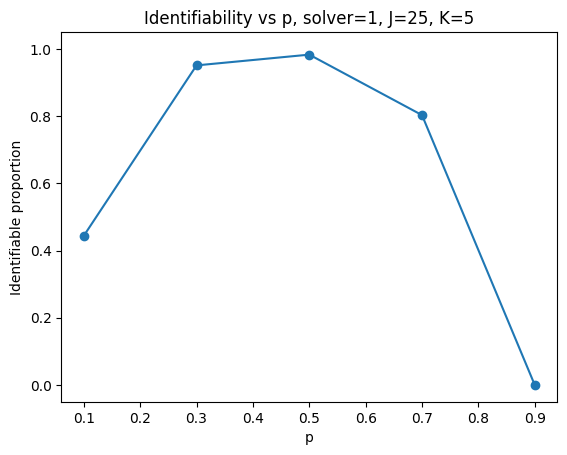

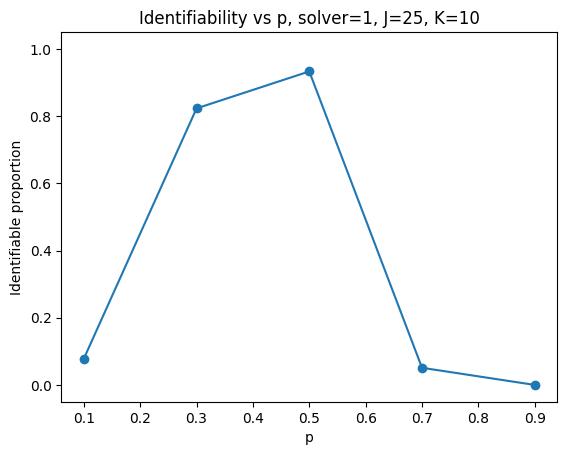

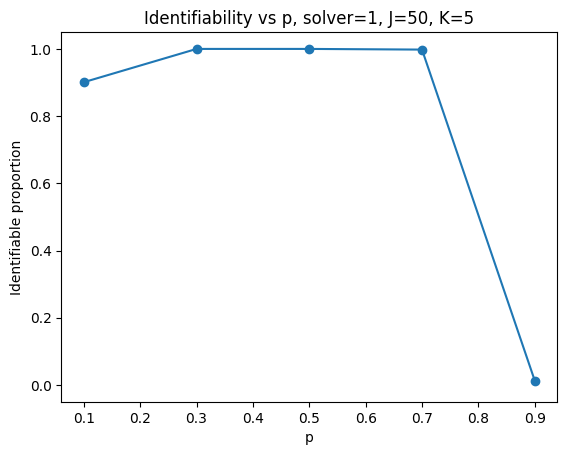

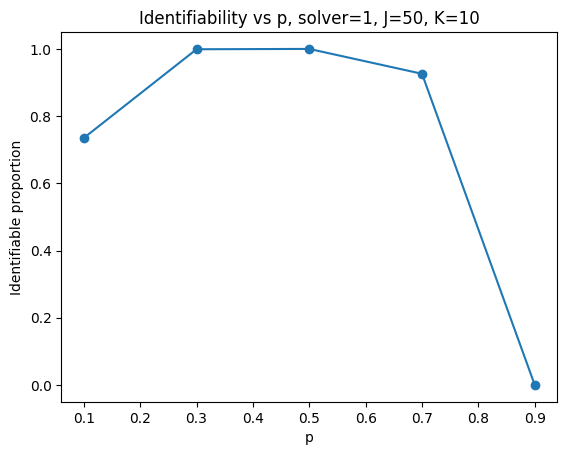

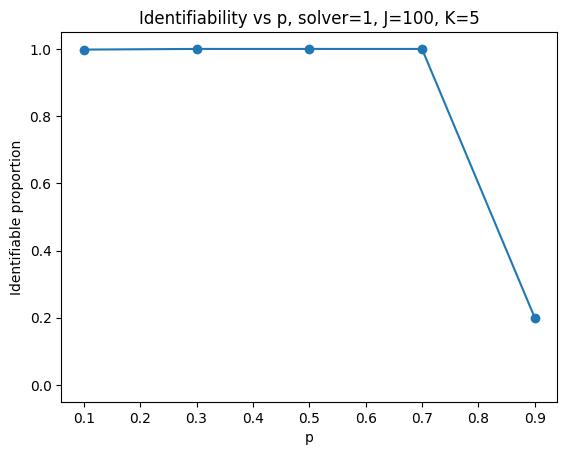

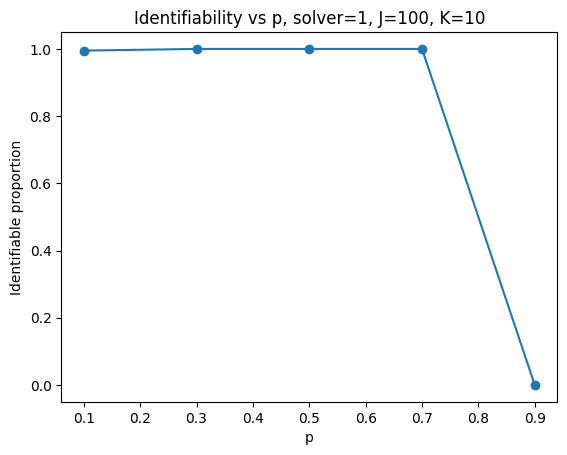

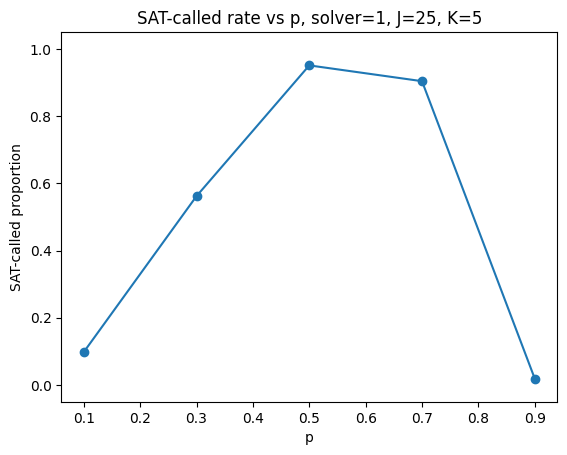

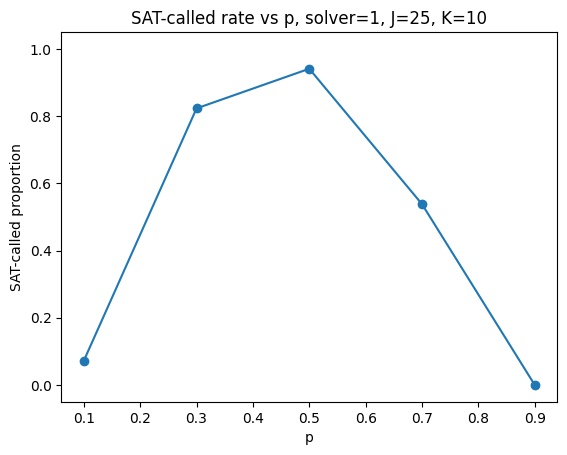

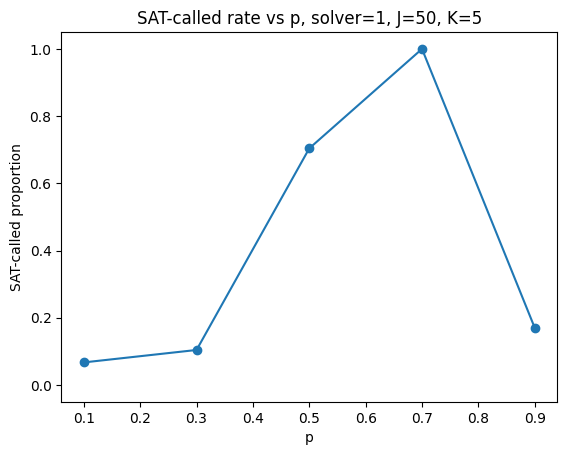

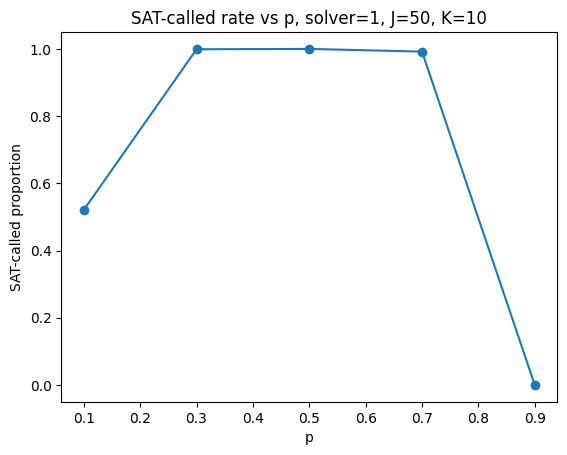

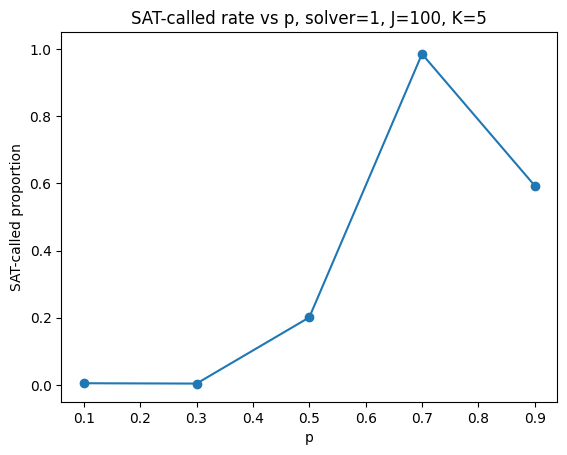

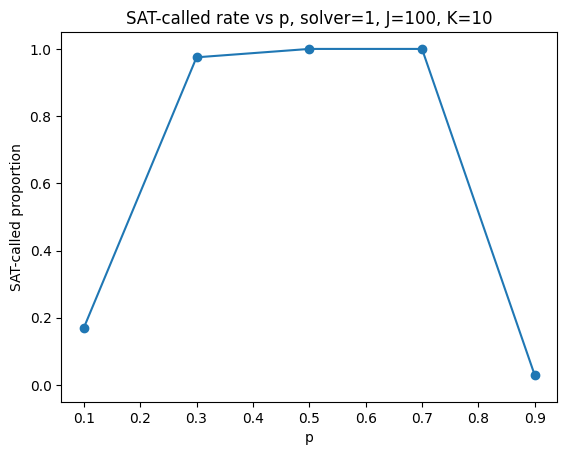

In [31]:
import matplotlib.pyplot as plt

plot_df = alg_summary_full.copy()

# Plot identifiable proportion versus p for each (solver, J, K).
if len(plot_df) > 0:
    for (solver, J, K), g in plot_df.groupby(["solver", "J", "K"], dropna=False):
        g = g.sort_values("p")
        if g["p"].nunique() < 2:
            continue

        plt.figure()
        plt.plot(g["p"], g["id_prop"], marker="o")
        plt.xlabel("p")
        plt.ylabel("Identifiable proportion")
        plt.title(f"Identifiability vs p, solver={solver}, J={J}, K={K}")
        plt.ylim(-0.05, 1.05)
        plt.show()

# Plot SAT-called proportion versus p for each (solver, J, K).
if len(plot_df) > 0:
    for (solver, J, K), g in plot_df.groupby(["solver", "J", "K"], dropna=False):
        g = g.sort_values("p")
        if g["p"].nunique() < 2:
            continue

        plt.figure()
        plt.plot(g["p"], g["sat_called_prop"], marker="o")
        plt.xlabel("p")
        plt.ylabel("SAT-called proportion")
        plt.title(f"SAT-called rate vs p, solver={solver}, J={J}, K={K}")
        plt.ylim(-0.05, 1.05)
        plt.show()

## 12. Export results

This writes raw numeric tables, display-formatted tables, and LaTeX table files to `OUT_DIR`. With the recommended folder structure, `OUT_DIR` is `../data/processed`, so the raw seed-level CSVs remain untouched in `../data/raw`.


In [32]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Raw numeric tables.
df.to_csv(OUT_DIR / "merged_diagnostic_rows.csv", index=False)
alg_summary_full.to_csv(OUT_DIR / "algorithm_diagnostics_raw.csv", index=False)
branch_wide_compact.to_csv(OUT_DIR / "branch_proportions_raw.csv", index=False)
pure_gap.to_csv(OUT_DIR / "pure_node_gap_raw.csv", index=False)

# Display tables.
alg_paper_display.to_csv(OUT_DIR / "algorithm_diagnostics_display.csv", index=False)
branch_display.to_csv(OUT_DIR / "branch_proportions_display.csv", index=False)
pure_gap_display.to_csv(OUT_DIR / "pure_node_gap_display.csv", index=False)

# LaTeX tables.
with open(OUT_DIR / "algorithm_diagnostics_display.tex", "w") as f:
    f.write(alg_paper_display.to_latex(index=False, escape=False))

with open(OUT_DIR / "branch_proportions_display.tex", "w") as f:
    f.write(branch_display.to_latex(index=False, escape=False))

with open(OUT_DIR / "pure_node_gap_display.tex", "w") as f:
    f.write(pure_gap_display.to_latex(index=False, escape=False))

print(f"Exported tables to {OUT_DIR.resolve()}")
print("Files:")
for f in sorted(OUT_DIR.glob("*diagnostic*")) + sorted(OUT_DIR.glob("*branch*")) + sorted(OUT_DIR.glob("*pure_node*")):
    print("  ", f.name)

Exported tables to /home/lemonkey/idQ/data/processed
Files:
   algorithm_diagnostics_display.csv
   algorithm_diagnostics_display.tex
   algorithm_diagnostics_raw.csv
   merged_diagnostic_rows.csv
   branch_proportions_display.csv
   branch_proportions_display.tex
   branch_proportions_raw.csv
   pure_node_gap_display.csv
   pure_node_gap_display.tex
   pure_node_gap_raw.csv


## 13. Notes for interpretation

- Use `identity_original_prop` for the classical completeness/pure-node condition on the generated \(Q\).
- Use `identity_basis_prop`, `two_col_violation_basis_prop`, and branch proportions to explain the algorithm’s stopping behavior after basis reduction.
- Use `sat_called_prop` to report the fraction of simulations that actually reached SAT.
- Use `mean_sat_time_given_SAT`, not only `mean_sat_time_all`, to describe the computational cost of SAT among cases that reached it.
- For the pure-node gap, use only the original-\(Q\) indicators:
  - `id_and_not_complete_prop`
  - `not_complete_given_id`
  - `id_and_no_pure_prop`
  - `no_pure_given_id`